# SmartGridAI — Phase 3: Machine Learning Forecasting

Trains Random Forest and XGBoost forecasters on the Phase 2 feature matrix,
compares them against the Phase 2 naive baselines on the chronological
validation/test splits (MAE / RMSE / MAPE / R2), and visualizes the best model
forecast. Requires `python ml/scripts/train_models.py` and
`python ml/scripts/evaluate_models.py` to have been run.

All evaluation is strictly chronological (no shuffling): features are
backward-looking only, so no target leakage reaches the validation/test sets.
Model artifacts live in `ml/models/` and reports in
`ml/data/processed/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROCESSED = Path("../ml/data/processed")
MODELS = Path("../ml/models")

## 1. Feature Matrix and Splits

In [2]:
features = pd.read_parquet(PROCESSED / "features_hourly.parquet")
features.index = pd.to_datetime(features.index)
features = features.sort_index()

feature_cols = [c for c in features.columns if c not in ("consumption", "split")]
print(f"Rows: {len(features):,} | Features: {len(feature_cols)}")
print(features["split"].value_counts().rename("rows"))
summary = json.loads((PROCESSED / "model_metrics.json").read_text(encoding="utf-8"))
print("\nFeature columns:")
for group, cols in {
    "timestamp": ["hour", "day", "day_of_week", "day_of_month", "week_of_year",
                  "month", "quarter", "year", "is_weekend"],
    "lags": [c for c in feature_cols if c.startswith("lag_")],
    "rolling": [c for c in feature_cols if c.startswith("rolling_")],
}.items():
    print(f"  {group}: {', '.join(cols)}")

Rows: 34,860 | Features: 21
split
train         24402
validation     5229
test           5229
Name: rows, dtype: int64

Feature columns:
  timestamp: hour, day, day_of_week, day_of_month, week_of_year, month, quarter, year, is_weekend
  lags: lag_1, lag_2, lag_3, lag_24, lag_48, lag_72, lag_168
  rolling: rolling_mean_3h, rolling_mean_6h, rolling_mean_12h, rolling_mean_24h, rolling_mean_7d


## 2. Model Metrics (validation + test)

In [3]:
metrics_report = json.loads((PROCESSED / "model_comparison.json").read_text(encoding="utf-8"))

rows = []
for name, m in metrics_report["models"].items():
    for split in ("validation", "test"):
        rows.append({"model": name, "split": split, **m["splits"].get(split, {})})
table = pd.DataFrame(rows).set_index(["model", "split"])
print(table.to_string())

print("\nBest model (lowest validation MAE):")
best = pd.Series(metrics_report["best_model"])
print(f"  {best['name']}")
print(f"  validation MAE {best['validation']['mae']} | test MAE {best['test']['mae']}")

                               mae     rmse   mape    r2
model          split                                    
random_forest  validation   319.14   547.10   1.11  0.99
               test         307.47   474.73   1.06  0.99
xgboost        validation   276.24   458.50   0.97  0.99
               test         260.61   404.87   0.90  0.99
previous_hour  validation  1114.99  1507.04   3.91  0.90
               test        1047.25  1385.71   3.69  0.91
previous_day   validation  2445.68  3519.03   8.49  0.44
               test        2530.83  3624.32   8.75  0.37
moving_average validation  3464.07  4182.82  12.52  0.22
               test        3511.39  4199.27  12.67  0.16

Best model (lowest validation MAE):
  xgboost
  validation MAE 276.24 | test MAE 260.61


## 3. Test-Set MAE by Model

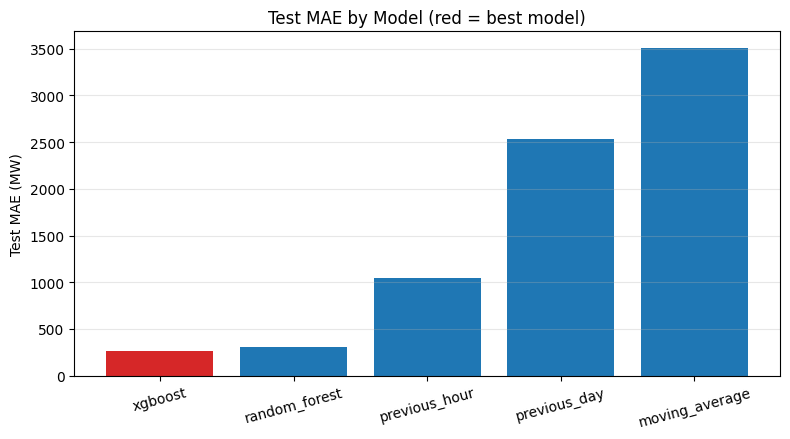

In [4]:
mae_by_model = table.xs("test", level="split")["mae"].sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#d62728" if m == metrics_report["best_model"]["name"] else "#1f77b4"
          for m in mae_by_model.index]
ax.bar(mae_by_model.index, mae_by_model.values, color=colors)
ax.set_ylabel("Test MAE (MW)")
ax.set_title("Test MAE by Model (red = best model)")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
fig.tight_layout()
plt.savefig(PROCESSED / "_mae_comparison.png", dpi=110)
plt.show()

## 4. Forecast vs Actual (best model on last 14 days of test)

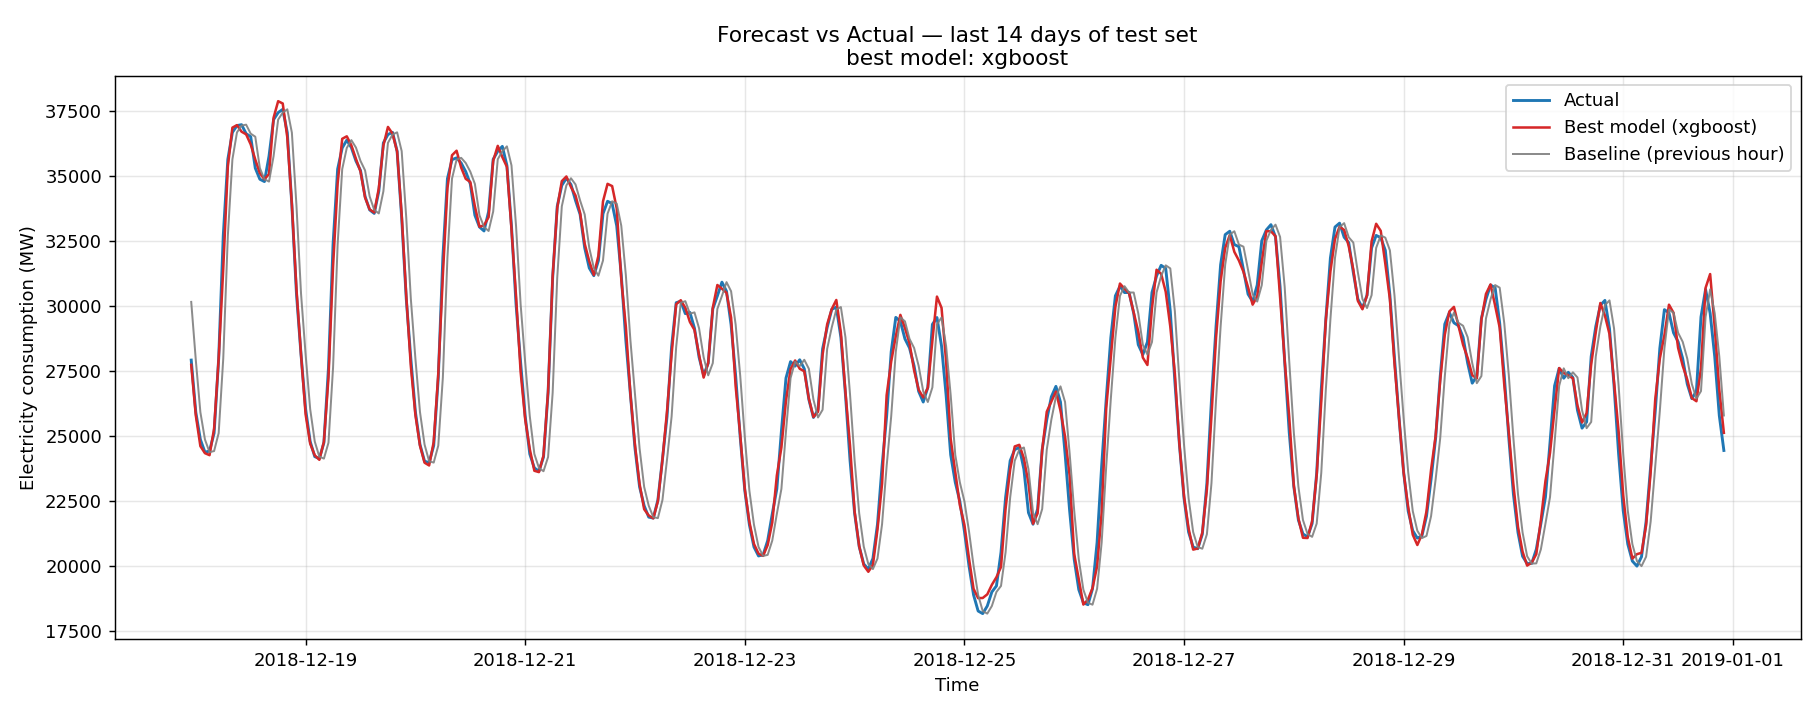

In [5]:
from IPython.display import Image, display
display(Image(filename=str(PROCESSED / "forecast_plot.png")))

## 5. Sample Predictions

In [6]:
preds = pd.read_csv(PROCESSED / "predictions.csv", parse_dates=["timestamp"])
preds.tail(10)

,timestamp,split,actual,random_forest,xgboost
20906,2018-12-31 18:00:00,test,30653.0,NaN,30708.262
20907,2018-12-31 18:00:00,test,30653.0,30738.520972,NaN
20908,2018-12-31 19:00:00,test,29735.0,NaN,31241.168
20909,2018-12-31 19:00:00,test,29735.0,31144.871705,NaN
20910,2018-12-31 20:00:00,test,28071.0,NaN,29192.440
20911,2018-12-31 20:00:00,test,28071.0,29272.753190,NaN
20912,2018-12-31 21:00:00,test,25801.0,NaN,26790.115
20913,2018-12-31 21:00:00,test,25801.0,26548.604474,NaN
20914,2018-12-31 22:00:00,test,24455.0,24186.345944,NaN
20915,2018-12-31 22:00:00,test,24455.0,NaN,25133.719


## 6. Summary

In [7]:
best = metrics_report["best_model"]
splits_used = metrics_report["splits_used"]
print(f"Models tested: {', '.join(metrics_report['models'])}")
print(f"Metrics: {', '.join(metrics_report['metrics'])}")
print(f"Best model: {best['name']} "
      f"(validation MAE {best['validation']['mae']} MW, "
      f"test MAE {best['test']['mae']} MW, "
      f"test R2 {best['test']['r2']})")
print(f"Training period: {splits_used['train']['start']} -> {splits_used['train']['end']}")
print(f"Validation period: {splits_used['validation']['start']} -> "
      f"{splits_used['validation']['end']}")
print(f"Test period: {splits_used['test']['start']} -> {splits_used['test']['end']}")
print(f"Saved models: {[p.name for p in sorted(MODELS.glob('*.joblib'))]}")

Models tested: random_forest, xgboost, previous_hour, previous_day, moving_average
Metrics: mae, rmse, mape, r2
Best model: xgboost (validation MAE 276.24 MW, test MAE 260.61 MW, test R2 0.99)
Training period: 2015-01-08 05:00:00 -> 2017-10-22 00:00:00
Validation period: 2017-10-22 01:00:00 -> 2018-05-27 23:00:00
Test period: 2018-05-28 00:00:00 -> 2018-12-31 22:00:00
Saved models: ['random_forest.joblib', 'xgboost.joblib']
